
**SVM classification for lung cancer survival prediction. The target variable is survived, where 1 means the patient survived and 0 means the patient did not survive. This is a binary classification problem, and I use Support Vector Machines to build and evaluate classification models**



**SVM is suitable for this classification problem because it can separate different classes. Since the data is imbalanced and large, I use balanced SVM models, different evaluation metrics, and feature scaling.**

**Import Libraries and Load Dataset**

In [ ]:
import os, time, warnings
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import LinearSVC, SVC
from sklearn.dummy import DummyClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.metrics import (roc_auc_score, average_precision_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score, matthews_corrcoef,
                             accuracy_score, ConfusionMatrixDisplay, classification_report)
warnings.filterwarnings("ignore")

# Colab: unzip the dataset if the csv is not already there
CSV = "lung_cancer_processed.csv"
if not os.path.exists(CSV):
    CSV = "/content/lung_cancer_processed.csv"
    if not os.path.exists(CSV):
        !unzip -o /content/lung_cancer_processed.zip -d /content/

df = pd.read_csv(CSV)
print("Loaded:", CSV)

Loaded: lung_cancer_processed.csv


## 2. Data check
**In this cell, I check the dataset size, missing values, duplicate rows, and the target distribution to make sure the dataset is complete and ready for model training**


In [ ]:
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum(), "| Duplicate rows:", df.duplicated().sum())
assert df.shape == (886105, 22) and df.isna().sum().sum() == 0, "Dataset looks incomplete - re-upload the full zip!"

print("\nTarget distribution:")
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True).round(4))

Shape: (886105, 22)
Missing values: 0 | Duplicate rows: 0

Target distribution:
survived
0    690979
1    195126
Name: count, dtype: int64
survived
0    0.7798
1    0.2202
Name: proportion, dtype: float64


**Observation:** The data is imbalanced, with about 78% in class 0 and 22% in class 1. So, accuracy alone is not reliable.

## 3. Train/test split and preprocessing

**In this cell, I separate the input features and the target variable. Then I split the data into 80% training data and 20% testing data. I scale the numerical features using StandardScaler and convert the country column into numerical values using OneHotEncoder. This prepares the data for model training.**

In [ ]:
X = df.drop(columns="survived")
y = df["survived"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

num_cols = ["age", "bmi", "cholesterol_level", "treatment_duration_days", "diagnosis_year"]
cat_cols = ["country"]

prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

Train: (708884, 21)  Test: (177221, 21)


## 4. Validation method and evaluation metrics
**In this cell, I set up 5-fold stratified cross-validation to evaluate the models fairly while keeping the class ratio. I use ROC-AUC, Average Precision, Balanced Accuracy, and F1 score as evaluation metrics. Then I create functions to run cross-validation and calculate the mean and standard deviation of each metric. Finally, I test a Dummy Classifier as a baseline for comparison.**

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"auc": "roc_auc", "ap": "average_precision",
           "bal_acc": "balanced_accuracy", "f1": "f1"}

cv_rows = {}
def run_cv(name, model, Xt=None, yt=None, n_jobs=-1):
    Xt = X_train if Xt is None else Xt
    yt = y_train if yt is None else yt
    t = time.time()
    r = cross_validate(model, Xt, yt, cv=cv, scoring=scoring, n_jobs=n_jobs)
    cv_rows[name] = {k: (r["test_"+k].mean(), r["test_"+k].std()) for k in scoring}
    print(f"{name:32s}", {k: f"{m:.3f}±{s:.3f}" for k, (m, s) in cv_rows[name].items()},
          f"({time.time()-t:.0f}s)")

def make(clf):
    return Pipeline([("prep", prep), ("svm", clf)])

run_cv("Baseline (Dummy)", Pipeline([("m", DummyClassifier(strategy="prior"))]))

Baseline (Dummy)                 {'auc': '0.500±0.000', 'ap': '0.220±0.000', 'bal_acc': '0.500±0.000', 'f1': '0.000±0.000'} (7s)


## 5. Models trained
**“I train three initial SVM models. The first is a standard Linear SVM. The second is a Balanced Linear SVM, which gives more importance to the minority class. The third uses Nystroem to approximate an RBF kernel, because the dataset is very large. I set n_jobs=1 for this model to reduce memory usage.”**

In [ ]:
run_cv("1 Linear SVM",          make(LinearSVC(C=1.0, dual=False, random_state=42)))
run_cv("2 Balanced Linear SVM", make(LinearSVC(C=1.0, dual=False, class_weight="balanced", random_state=42)))
run_cv("3 Balanced RBF-approx",
       Pipeline([("prep", prep), ("nys", Nystroem(gamma=0.01, n_components=300, random_state=42)),
                 ("svm", LinearSVC(dual=False, class_weight="balanced", random_state=42))]),
       n_jobs=1)   # n_jobs=1: the 300-column Nystroem matrix is large, avoids running out of RAM

1 Linear SVM                     {'auc': '0.501±0.001', 'ap': '0.221±0.001', 'bal_acc': '0.500±0.000', 'f1': '0.000±0.000'} (13s)
2 Balanced Linear SVM            {'auc': '0.501±0.001', 'ap': '0.221±0.001', 'bal_acc': '0.500±0.001', 'f1': '0.308±0.001'} (19s)
3 Balanced RBF-approx            {'auc': '0.500±0.002', 'ap': '0.221±0.001', 'bal_acc': '0.500±0.001', 'f1': '0.306±0.001'} (1385s)


## 6. Hyper-parameter tuning (GridSearchCV)
**I use GridSearchCV to find the best C value for the Balanced Linear SVM. I test different C values using 5-fold cross-validation and use ROC-AUC to compare the results. Finally, the code selects the C value that gives the best cross-validation performance.**

In [ ]:
t = time.time()
grid_lin = GridSearchCV(
    make(LinearSVC(dual=False, class_weight="balanced", random_state=42)),
    {"svm__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring="roc_auc", n_jobs=-1)
grid_lin.fit(X_train, y_train)
print("Linear best params:", grid_lin.best_params_, " CV AUC: %.4f" % grid_lin.best_score_, f"({time.time()-t:.0f}s)")
print(pd.DataFrame(grid_lin.cv_results_)[["param_svm__C", "mean_test_score", "std_test_score"]].round(4))

Linear best params: {'svm__C': 0.001}  CV AUC: 0.5011 (106s)
   param_svm__C  mean_test_score  std_test_score
0         0.001           0.5011          0.0012
1         0.010           0.5011          0.0012
2         0.100           0.5011          0.0012
3         1.000           0.5011          0.0012
4        10.000           0.5011          0.0012
5       100.000           0.5011          0.0012


**I take a stratified sample of 15,000 training records for the true RBF SVM. I do this because the full dataset is very large and RBF SVM is computationally expensive. Then I use GridSearchCV to test different C and gamma values using 3-fold cross-validation. Finally, I select the combination that gives the best ROC-AUC.**

In [ ]:
# stratified subsample for the true RBF SVM
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=15000,
                                      stratify=y_train, random_state=42)
print("RBF subsample:", X_sub.shape, " class-1 rate: %.3f" % y_sub.mean())

t = time.time()
grid_rbf = GridSearchCV(
    make(SVC(kernel="rbf", class_weight="balanced")),
    {"svm__C": [0.1, 1, 10, 100], "svm__gamma": [0.001, 0.01, 0.1, 1]},
    cv=StratifiedKFold(3, shuffle=True, random_state=42), scoring="roc_auc", n_jobs=-1)
grid_rbf.fit(X_sub, y_sub)
print("RBF best params:", grid_rbf.best_params_, " CV AUC: %.4f" % grid_rbf.best_score_, f"({time.time()-t:.0f}s)")
res = pd.DataFrame(grid_rbf.cv_results_)
print(res.pivot(index="param_svm__C", columns="param_svm__gamma", values="mean_test_score").round(4))

RBF subsample: (15000, 21)  class-1 rate: 0.220
RBF best params: {'svm__C': 10, 'svm__gamma': 1}  CV AUC: 0.5101 (909s)
param_svm__gamma   0.001   0.010   0.100   1.000
param_svm__C                                    
0.1               0.5069  0.5064  0.5070  0.5101
1.0               0.5058  0.5009  0.5049  0.5098
10.0              0.5014  0.4965  0.5036  0.5101
100.0             0.4959  0.5057  0.5046  0.5101


## 7. Final evaluation
**I create the five final SVM models and test them on the untouched test data. I calculate several performance measures, including Accuracy, Balanced Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, and MCC. I also add a reference model that predicts class 1 for everyone. Finally, I store all the results in a table so I can compare the models.”**



In [ ]:
final_models = {
    "1 Linear SVM":                 make(LinearSVC(C=1.0, dual=False, random_state=42)),
    "2 Balanced Linear SVM":        make(LinearSVC(C=1.0, dual=False, class_weight="balanced", random_state=42)),
    "3 Balanced RBF-approx":        Pipeline([("prep", prep), ("nys", Nystroem(gamma=0.01, n_components=300, random_state=42)),
                                              ("svm", LinearSVC(dual=False, class_weight="balanced", random_state=42))]),
    "4 Tuned Balanced Linear":      grid_lin.best_estimator_,
    "5 Tuned Balanced RBF (SVC)":   grid_rbf.best_estimator_,
}
rows, preds = [], {}
for name, m in final_models.items():
    if name[0] in "123":
        m.fit(X_train, y_train)
    pred = m.predict(X_test); score = m.decision_function(X_test)
    preds[name] = pred
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Balanced Acc": balanced_accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred, zero_division=0),
                 "Recall": recall_score(y_test, pred, zero_division=0),
                 "F1": f1_score(y_test, pred, zero_division=0),
                 "ROC-AUC": roc_auc_score(y_test, score),
                 "PR-AUC": average_precision_score(y_test, score),
                 "MCC": matthews_corrcoef(y_test, pred)})

# reference rule: predict "1" for everyone
allpos = np.ones(len(y_test), dtype=int)
rows.append({"Model": "Reference: predict everyone = 1",
             "Accuracy": accuracy_score(y_test, allpos), "Balanced Acc": balanced_accuracy_score(y_test, allpos),
             "Precision": precision_score(y_test, allpos), "Recall": recall_score(y_test, allpos),
             "F1": f1_score(y_test, allpos), "ROC-AUC": 0.5, "PR-AUC": y_test.mean(), "MCC": 0.0})

results = pd.DataFrame(rows).set_index("Model").round(4)
print("Class-1 base rate in test set: %.4f\n" % y_test.mean())
results

Class-1 base rate in test set: 0.2202



,Accuracy,Balanced Acc,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,,,
1 Linear SVM,0.7798,0.5000,0.0000,0.0000,0.0000,0.4999,0.2193,0.0000
2 Balanced Linear SVM,0.4937,0.5010,0.2209,0.5139,0.3090,0.4999,0.2193,0.0016
3 Balanced RBF-approx,0.4996,0.5003,0.2204,0.5014,0.3062,0.5001,0.2197,0.0004
4 Tuned Balanced Linear,0.4937,0.5007,0.2207,0.5132,0.3086,0.4999,0.2193,0.0011
5 Tuned Balanced RBF (SVC),0.7793,0.5000,0.2112,0.0009,0.0017,0.4985,0.2194,-0.0007
Reference: predict everyone = 1,0.2202,0.5000,0.2202,1.0000,0.3609,0.5000,0.2202,0.0000


**I create confusion matrices to see the correct and incorrect predictions of the three SVM models**

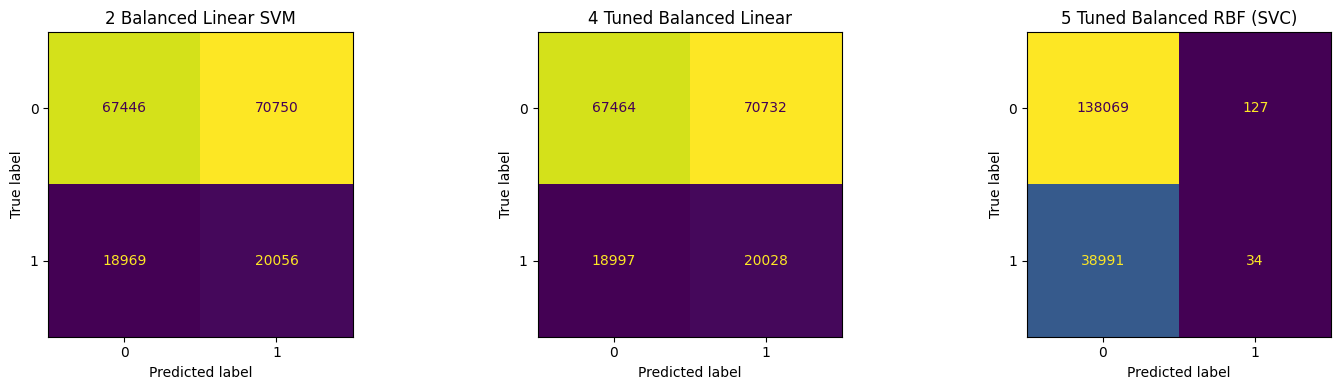

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ["2 Balanced Linear SVM", "4 Tuned Balanced Linear", "5 Tuned Balanced RBF (SVC)"]):
    ConfusionMatrixDisplay.from_predictions(y_test, preds[name], ax=ax, colorbar=False, values_format="d")
    ax.set_title(name)
plt.tight_layout(); plt.show()

**I compare the cross-validation scores of the models using the mean and standard deviation from 5-fold cross-validation**

In [ ]:
# comparison of cross-validation scores (mean ± std, 5-fold) for models 1-3 and the baseline
pd.DataFrame({n: {k: f"{m:.3f} ± {s:.3f}" for k, (m, s) in v.items()} for n, v in cv_rows.items()}).T

,auc,ap,bal_acc,f1
Baseline (Dummy),0.500 ± 0.000,0.220 ± 0.000,0.500 ± 0.000,0.000 ± 0.000
1 Linear SVM,0.501 ± 0.001,0.221 ± 0.001,0.500 ± 0.000,0.000 ± 0.000
2 Balanced Linear SVM,0.501 ± 0.001,0.221 ± 0.001,0.500 ± 0.001,0.308 ± 0.001
3 Balanced RBF-approx,0.500 ± 0.002,0.221 ± 0.001,0.500 ± 0.001,0.306 ± 0.001


## 8. Sanity check

**I use Logistic Regression and Gradient Boosting as additional models to check whether the low SVM performance is caused by the SVM algorithm. I also check which single feature has the strongest relationship with the target.**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

lr = make(LogisticRegression(class_weight="balanced", max_iter=500)).fit(X_train, y_train)
gb = HistGradientBoostingClassifier(random_state=42).fit(X_train, y_train)
print("Logistic Regression  test AUC: %.4f" % roc_auc_score(y_test, lr.decision_function(X_test)))
print("Gradient Boosting    test AUC: %.4f" % roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1]))

# strongest single-feature signal
auc_dev = {c: abs(roc_auc_score(y_train, X_train[c]) - 0.5) for c in X_train.columns}
print("\nLargest single-feature |AUC-0.5|:", max(auc_dev.items(), key=lambda kv: kv[1]))

Logistic Regression  test AUC: 0.5000
Gradient Boosting    test AUC: 0.4997

Largest single-feature |AUC-0.5|: ('cancer_stage', np.float64(0.002403314813653301))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Conclusion
**Overall, I trained and compared different SVM models. Among them, the Balanced Linear SVM performed better for detecting the minority class. However, the overall results were close to random-chance level, with ROC-AUC around 0.50. Therefore, the available features were not strong enough to predict lung cancer survival accurately, so these SVM models are not suitable for reliable prediction.**